<a href="https://colab.research.google.com/github/louyang-ly/MAT509-Final-Project/blob/main/MATH_509_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install Packages

In [ ]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import autocorrelation_plot
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout

## 2. Import the Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Stock.csv')

## 3. Explore the Data

In [ ]:
data.head()
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          2514 non-null   object 
 1   Open          2514 non-null   float64
 2   High          2514 non-null   float64
 3   Low           2514 non-null   float64
 4   Close         2514 non-null   float64
 5   Volume        2514 non-null   int64  
 6   Dividends     2514 non-null   float64
 7   Stock Splits  2514 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 157.3+ KB


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03,2514.000000,2514.0
mean,131.865838,133.145860,130.631622,131.920004,1.305751e+07,0.014407,0.0
std,68.566197,69.252095,67.917625,68.621258,6.331427e+06,0.118943,0.0
min,44.456308,45.010954,43.947892,44.155876,3.220500e+06,0.000000,0.0
25%,85.908112,86.711053,85.104724,85.847872,8.917700e+06,0.000000,0.0
50%,111.510762,112.375558,110.123527,111.748806,1.160375e+07,0.000000,0.0
75%,147.322604,148.684884,146.549356,147.464157,1.508955e+07,0.000000,0.0
max,332.619995,335.869995,330.649994,334.609985,5.619230e+07,1.500000,0.0


In [ ]:
# Transform the variable date to the datetime format
data['Date'] = pd.to_datetime(data['Date'])
# Sort the variable datetime
data = data.sort_values('Date')
data = data.reset_index(drop=True)

/tmp/ipykernel_130127/4059768755.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data['Date'] = pd.to_datetime(data['Date'])


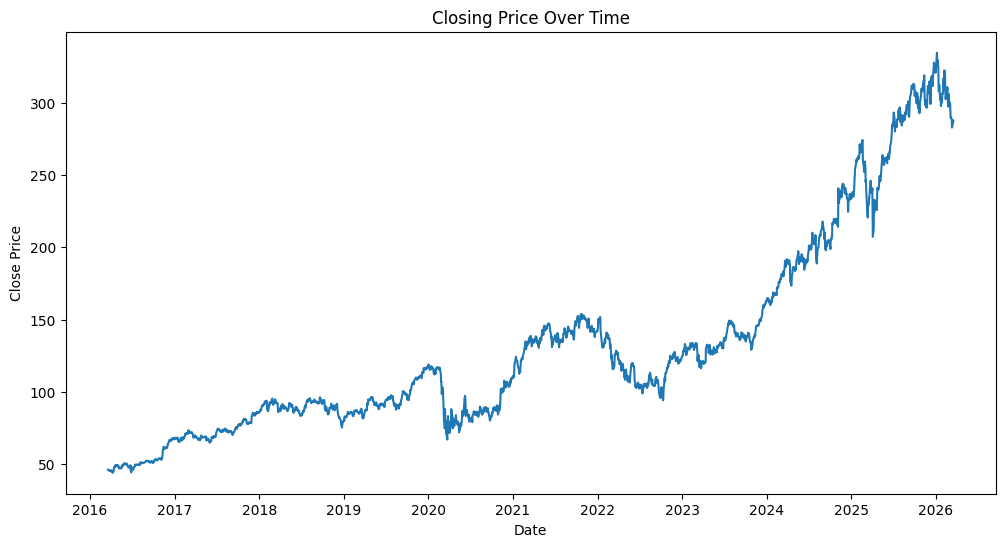

In [ ]:
# Trend Analysis
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'])
plt.title('Closing Price Over Time'); plt.xlabel('Date'); plt.ylabel('Close Price'); plt.show()

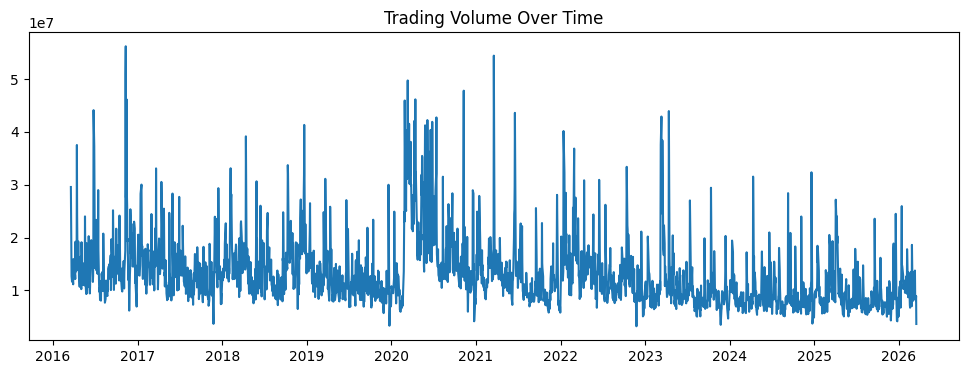

In [ ]:
# Volumn
plt.figure(figsize=(12,4))
plt.plot(data['Date'], data['Volume']); plt.title('Trading Volume Over Time'); plt.show()

In [ ]:
# Return
data['Return'] = data['Close'].pct_change()
data = data.dropna()

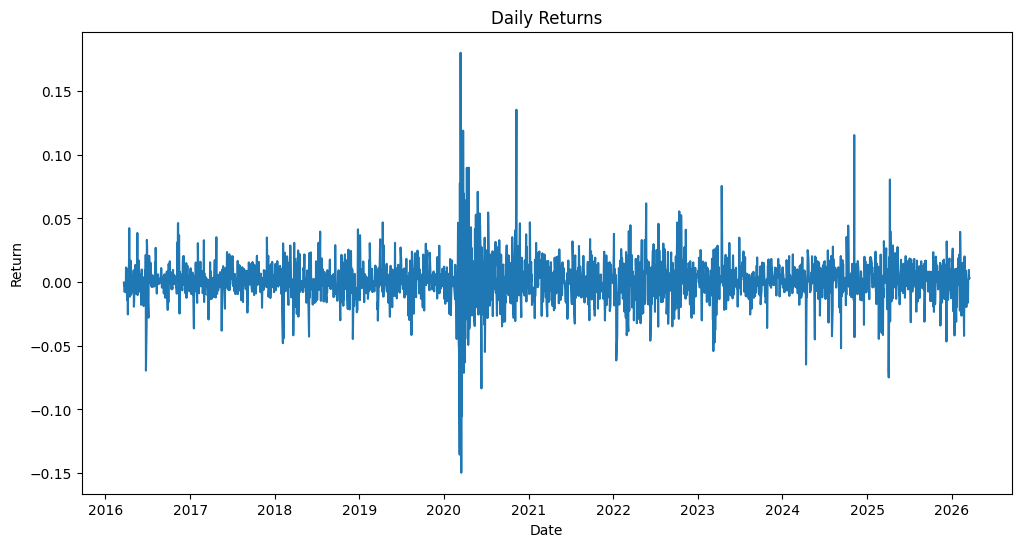

In [ ]:
# Volatility Check
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Return'])
plt.title('Daily Returns'); plt.xlabel('Date'); plt.ylabel('Return'); plt.show();

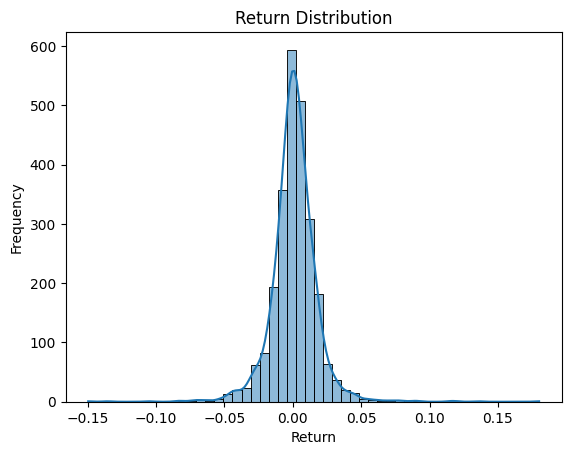

In [ ]:
# Distribution of Return
sns.histplot(data['Return'], bins=50, kde=True)
plt.title('Return Distribution'); plt.xlabel('Return'); plt.ylabel('Frequency'); plt.show();

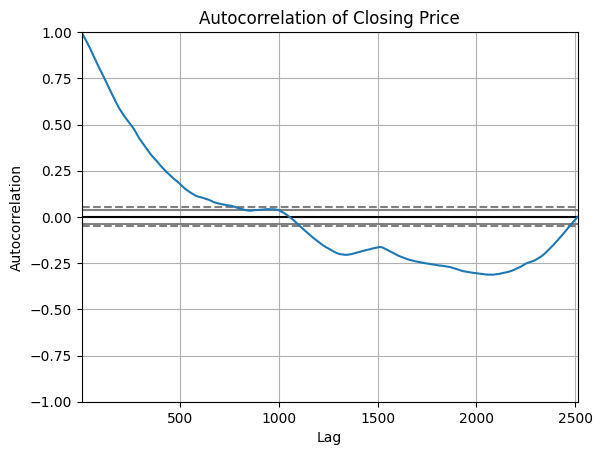

In [ ]:
# Autocorrelation Check
autocorrelation_plot(data['Close'])
plt.title('Autocorrelation of Closing Price'); plt.show()

## 4. Data Analysis

### 4.1 Feature Selection and Scaling

In [ ]:
# Feature Selection
FEATURES = ['High', 'Low', 'Open', 'Close', 'Volume']
data_features = data[FEATURES]
# Standardization
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_features)

### 4.2 Sliding Window and Train/Test Split

In [ ]:
# Set the sequence length = 50
sequence_length = 50
# Prediction Index
index_Close = FEATURES.index("Close")
# Train/Test Split
train_data_len = math.ceil(scaled_data.shape[0] * 0.8)
# Generate the Train/Test Data
train_data = scaled_data[0:train_data_len, :]
test_data = scaled_data[train_data_len - sequence_length:, :]
# Time Series Forecasting
def partition_dataset(sequence_length, data):
    x, y = [], []
    for i in range(sequence_length, len(data)):
        x.append(data[i-sequence_length:i, :])
        y.append(data[i, index_Close])
    return np.array(x), np.array(y)
# Generate training data and test data
x_test, y_test = partition_dataset(sequence_length, test_data)
x_train, y_train = partition_dataset(sequence_length, train_data)
# Print the shapes
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
# Validate that the prediction value and the input match up
print(x_train[1][sequence_length-1][index_Close])
print(y_train[0])

(1961, 50, 5) (1961,)
(502, 50, 5) (502,)
0.022198833681841168
0.022198833681841168


### 4.3 Long Short-Term Memory Neural Network (LSTM)

#### 4.3.1 Define the Neural Network Model

In [ ]:
# Initialize the sequential model
model = Sequential()

# Define number of neurons
n_neurons = x_train.shape[1] * x_train.shape[2]

# First LSTM layer (Receive the input)
model.add(LSTM(
    n_neurons,
    return_sequences=True,
    input_shape=(x_train.shape[1], x_train.shape[2])
))

# Second LSTM layer (Show the output)
model.add(LSTM(
    n_neurons,
    return_sequences=False
))

# Fully connected (Dense) layer
model.add(Dense(5))

# Output layer (Prediction)
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### 4.3.2 Optimize the model via ADAM+MSE

In [ ]:
# Compile the model (ADAM Optimizer)
model.compile(optimizer='adam', loss='mse')

# Training parameters
epochs = 50
batch_size = 16

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 340ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 38s 306ms/step - loss: 1.1644e-04 - val_loss: 6.0950e-04
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 40s 327ms/step - loss: 1.1615e-04 - val_loss: 4.8605e-04
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 38s 310ms/step - loss: 1.0830e-04 - val_loss: 7.0087e-04
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 39s 314ms/step - loss: 1.0011e-04 - val_loss: 9.4426e-04
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 38s 309ms/step - loss: 1.1080e-04 - val_loss: 4.4675e-04
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 38s 312ms/step - loss: 8.4397e-05 - val_loss: 4.1211e-04
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 39s 319ms/step - loss: 8.7488e-05 - val_loss: 9.0175e-04
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 38s 311ms/step - loss: 9.0015e-05 - val_loss: 0.0022
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 41s 336ms/step - loss: 8.3928e-05 - val_loss: 3.0248e-04
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 

#### 4.4 Plotting the Loss

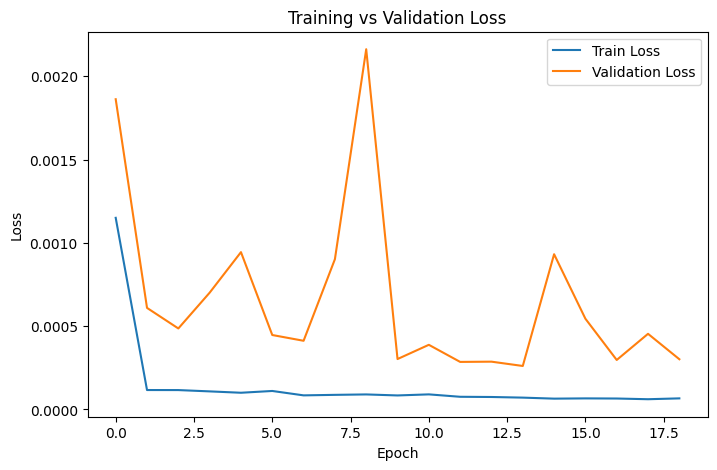

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(); plt.title('Training vs Validation Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show();

In [ ]:
# Get the predicted values (scaled)
y_pred_scaled = model.predict(x_test)

# Create dummy arrays for inverse transformation
y_pred_dummy = np.zeros((len(y_pred_scaled), scaled_data.shape[1]))
y_test_dummy = np.zeros((len(y_test), scaled_data.shape[1]))

# Put Close values into the correct column
y_pred_dummy[:, index_Close] = y_pred_scaled.flatten()
y_test_dummy[:, index_Close] = y_test.flatten()

# Inverse transform to original scale
y_pred = scaler.inverse_transform(y_pred_dummy)[:, index_Close]
y_test_unscaled = scaler.inverse_transform(y_test_dummy)[:, index_Close]

# Mean Absolute Error (MAE)
MAE = mean_absolute_error(y_test_unscaled, y_pred)
print(f'Mean Absolute Error (MAE): {np.round(MAE, 2)}')

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean(np.abs((y_test_unscaled - y_pred) / y_test_unscaled)) * 100
print(f'Mean Absolute Percentage Error (MAPE): {np.round(MAPE, 2)} %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median(np.abs((y_test_unscaled - y_pred) / y_test_unscaled)) * 100
print(f'Median Absolute Percentage Error (MDAPE): {np.round(MDAPE, 2)} %')

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step
Mean Absolute Error (MAE): 3.42
Mean Absolute Percentage Error (MAPE): 1.38 %
Median Absolute Percentage Error (MDAPE): 1.04 %


#### 4.5 Prediction Outcome

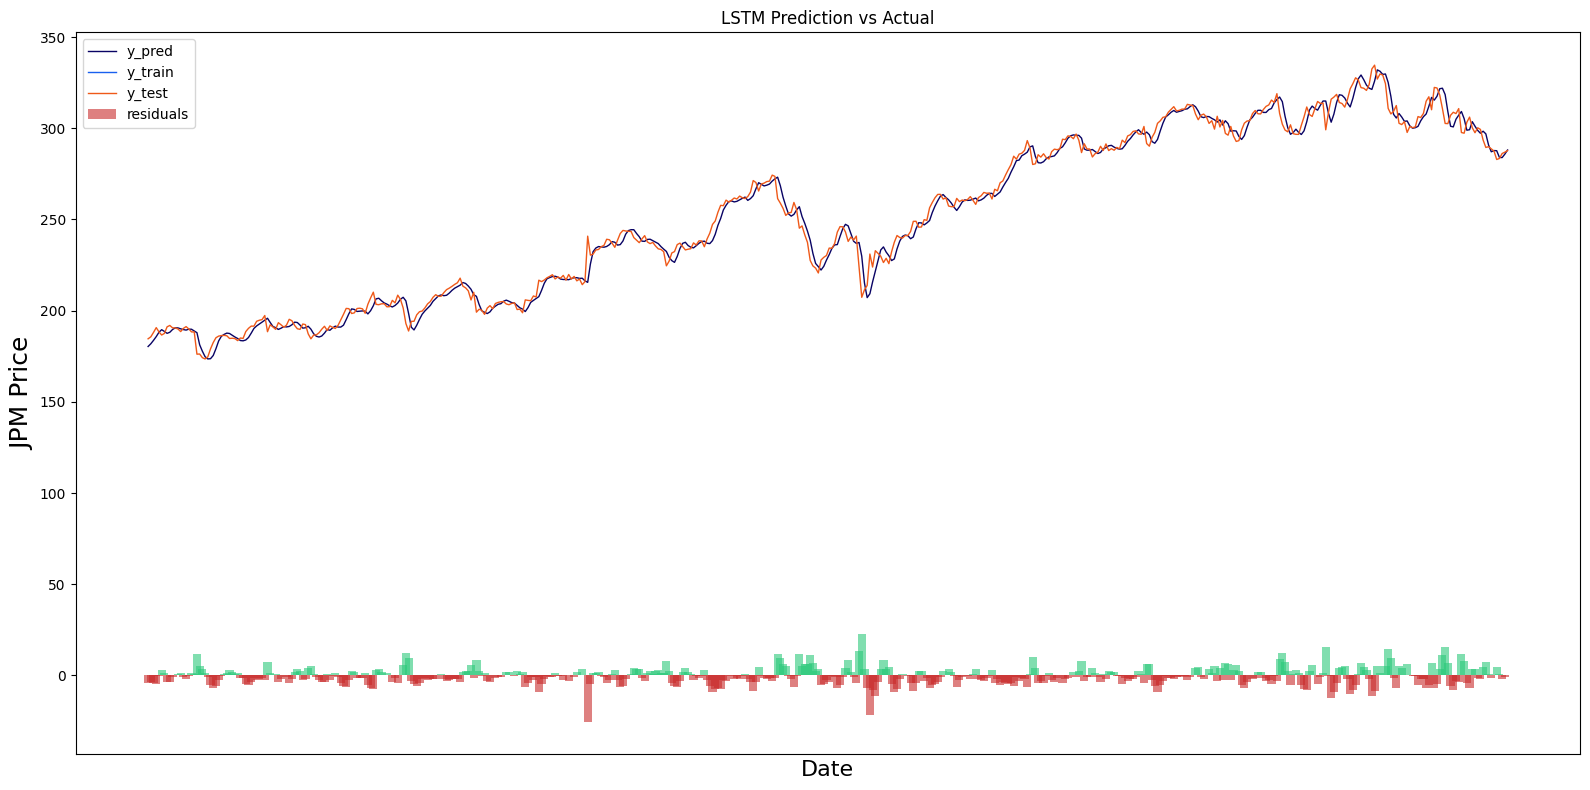

In [ ]:
# Prepare data
plot_data = data.copy()

# Set display start date
display_start_date = plot_data.index[train_data_len]

# Build train dataset
train = pd.DataFrame(
    plot_data['Close'][:train_data_len]
).rename(columns={'Close': 'y_train'})

# Build validation dataset
valid = pd.DataFrame(
    plot_data['Close'][train_data_len:]
).rename(columns={'Close': 'y_test'})

# Add predictions
valid['y_pred'] = y_pred

# Add residuals
valid['residuals'] = valid['y_pred'] - valid['y_test']

# Combine datasets
df_union = pd.concat([train, valid])

# Zoom into test period
df_union_zoom = df_union.loc[display_start_date:]

# Visualization
fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title("LSTM Prediction vs Actual"); plt.ylabel("JPM Price", fontsize=18)

sns.set_palette(["#090364", "#1960EF", "#EF5919"])
sns.lineplot(
    data=df_union_zoom[['y_pred', 'y_train', 'y_test']],
    linewidth=1.0,
    dashes=False,
    ax=ax1
)

# Plot residuals (bar)
df_sub = [
    "#2BC97A" if x > 0 else "#C92B2B"
    for x in df_union_zoom['residuals'].dropna()
]

ax1.bar(
    x=df_union_zoom['residuals'].dropna().index,
    height=df_union_zoom['residuals'].dropna(),
    width=3,
    label='residuals',
    color=df_sub,
    alpha=0.6
)

ax1.set_xticks([])
ax1.set_xlabel("Date", fontsize=16)

plt.legend()
plt.tight_layout()
plt.show()